In [10]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 0. 自动路径嗅探
# ==========================================
def resolve_path(pattern):
    files = glob.glob(pattern, recursive=True)
    if not files:
        return None
    return files[0]

# ==========================================
# 1. 配置文件路径
# ==========================================
# 绝对裁判：C 模型的预测结果 (提供纯净先验)
C_PRIOR_PATTERN = "/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"

# 待审判的模型矩阵
MODELS_TO_COMPARE = {
    "V1_Base": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v1_base/run_v1_base",
    "V6_Res_MoE": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v6_res_moe/run_v6_res_moe",
    "V7_Soft_Top5": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v7_soft_top5/run_v7_soft_top5",
    "V8_S1_t10": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v8_s1_t10/run_v8_s1_t10",
    "V8_S5": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v8_s5/run_v8_s5",
    "V10_Conflict": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v10_conflict_both/run_v10_both"
}

# 绘图颜色规范 (严格对齐你的 4 象限逻辑)
palette = {
    'Pure AT (Wool)': '#d62728',     # 红
    'Pure CO (Gold)': '#2ca02c',     # 绿
    'AT & CO (Both)': '#ff7f0e',     # 橙
    'NT (Tail)': '#1f77b4'           # 蓝
}
cohort_order = ['Pure AT (Wool)', 'Pure CO (Gold)', 'AT & CO (Both)', 'NT (Tail)']

# ==========================================
# 2. 上帝视角：锚定四象限人群
# ==========================================
print("📥 [1/4] Loading external C-Prior as the Absolute Referee...")
c_path = resolve_path(C_PRIOR_PATTERN)
df_c = pd.read_csv(c_path)

p_always = df_c['y0_prob'] 
p_comp = np.clip(df_c['y1_prob'] - df_c['y0_prob'], 0, None)
p_never = np.clip(1.0 - df_c['y1_prob'], 0, None) 

th_always = p_always.quantile(0.90)
th_comp = p_comp.quantile(0.90)
th_never = p_never.quantile(0.90) 

is_at = p_always >= th_always
is_comp = p_comp >= th_comp

mask_both = is_at & is_comp
mask_pure_at = is_at & (~is_comp)
mask_pure_co = is_comp & (~is_at)
mask_nt = (p_never >= th_never) & (~is_at) & (~is_comp)

# 生成全局标签 (行号与所有 Test Set 严格对应)
global_cohorts = pd.Series('Others', index=df_c.index)
global_cohorts.loc[mask_nt] = 'NT (Tail)'
global_cohorts.loc[mask_pure_at] = 'Pure AT (Wool)'
global_cohorts.loc[mask_pure_co] = 'Pure CO (Gold)'
global_cohorts.loc[mask_both] = 'AT & CO (Both)'

# ==========================================
# 3. 均匀下采样 (全模型共享一套 Sample Index)
# ==========================================
print("⚖️ [2/4] Sampling identical indices for fair comparison...")
SAMPLES_PER_COHORT = 1500  

sampled_indices = []
for cohort in cohort_order:
    idx = global_cohorts[global_cohorts == cohort].index
    if len(idx) > SAMPLES_PER_COHORT:
        idx = np.random.choice(idx, SAMPLES_PER_COHORT, replace=False)
    sampled_indices.extend(idx)

# 生成基准 DataFrame
df_sample_base = pd.DataFrame({'Cohort': global_cohorts.loc[sampled_indices]})
df_sample_base['color'] = df_sample_base['Cohort'].map(palette)

# ==========================================
# 4. 遍历分析核心引擎 (t-SNE & 距离矩阵)
# ==========================================
print("\n🚀 [3/4] Starting Model Analysis Pipeline...")

for model_name, base_path in MODELS_TO_COMPARE.items():
    npz_path = os.path.join(base_path, "test_dist_embeddings.npz")
    if not os.path.exists(npz_path):
        print(f"⚠️ Missing NPZ for {model_name}, skipping...")
        continue
        
    print(f"\n➤ Analyzing {model_name}...")
    npz = np.load(npz_path)
    # 提取高维表征，并立刻根据 Sample Indices 截取
    emb_raw = npz['wb_shared_emb'][sampled_indices]
    
    # --------------------------------------------------
    # 🔬 科学度量：高维原始空间群集质心余弦距离 (Centroid Cosine Distance)
    # --------------------------------------------------
    centroids = []
    valid_cohorts = []
    
    for cohort in cohort_order:
        cohort_emb = emb_raw[df_sample_base['Cohort'] == cohort]
        if len(cohort_emb) > 0:
            # 计算该人群在原始高维空间的质心 (Mean Vector)
            centroids.append(cohort_emb.mean(axis=0))
            valid_cohorts.append(cohort)
            
    # 计算质心两两之间的 Cosine Distance (0 表示完全一致，1 表示正交，2 表示完全相反)
    dist_matrix = cosine_distances(centroids)
    
    # 绘制距离热力图
    plt.figure(figsize=(6, 5))
    sns.heatmap(dist_matrix, annot=True, cmap='Reds', fmt=".3f", 
                xticklabels=valid_cohorts, yticklabels=valid_cohorts,
                cbar_kws={'label': 'Cosine Distance (Higher = More Separated)'})
    plt.title(f"{model_name}\nHigh-Dim Centroid Distance", fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"./emb_dist_{model_name}.pdf", dpi=300)
    plt.close()
    
    # --------------------------------------------------
    # 🎨 视觉度量：PCA + t-SNE 降维映射
    # --------------------------------------------------
    pca_dim = min(50, emb_raw.shape[1])
    emb_pca = PCA(n_components=pca_dim).fit_transform(emb_raw)
    emb_2d = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000).fit_transform(emb_pca)
    
    # 注入坐标点
    df_plot = df_sample_base.copy()
    df_plot['tsne_1'] = emb_2d[:, 0]
    df_plot['tsne_2'] = emb_2d[:, 1]
    
    # 全局打乱防遮挡
    df_shuffled = df_plot.sample(frac=1.0, random_state=42).reset_index(drop=True)
    
    plt.figure(figsize=(12, 10), facecolor='white')
    ax = plt.axes()
    ax.set_facecolor('#F8F9FA')
    
    # 散点绘制
    ax.scatter(df_shuffled['tsne_1'], df_shuffled['tsne_2'], 
               c=df_shuffled['color'], s=20, alpha=0.75, edgecolors='none')
    
    # 构建图例
    import matplotlib.patches as mpatches
    legend_patches = [mpatches.Patch(color=palette[c], label=c) for c in cohort_order]
    legend = plt.legend(handles=legend_patches, title="Causal Cohorts", fontsize=12, loc='best', frameon=True)
    legend.get_frame().set_facecolor('white')
    
    plt.title(f"Latent Space (t-SNE): {model_name}", fontsize=20, pad=20, fontweight='bold')
    plt.xticks([]); plt.yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
        
    plt.tight_layout()
    plt.savefig(f"./emb_tsne_{model_name}.pdf", dpi=400)
    plt.close()
    
    print(f"   [Done] Saved emb_tsne_{model_name}.pdf and emb_dist_{model_name}.pdf")

print("\n🎉 [4/4] All embeddings analyzed and visualized successfully!")

📥 [1/4] Loading external C-Prior as the Absolute Referee...
⚖️ [2/4] Sampling identical indices for fair comparison...

🚀 [3/4] Starting Model Analysis Pipeline...

➤ Analyzing V1_Base...


/NAS/shith/anaconda3/envs/song1/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


   [Done] Saved emb_tsne_V1_Base.pdf and emb_dist_V1_Base.pdf

➤ Analyzing V6_Res_MoE...


/NAS/shith/anaconda3/envs/song1/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


   [Done] Saved emb_tsne_V6_Res_MoE.pdf and emb_dist_V6_Res_MoE.pdf

➤ Analyzing V7_Soft_Top5...


...

   [Done] Saved emb_tsne_V8_S1_t10.pdf and emb_dist_V8_S1_t10.pdf

➤ Analyzing V8_S5...


/NAS/shith/anaconda3/envs/song1/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


   [Done] Saved emb_tsne_V8_S5.pdf and emb_dist_V8_S5.pdf

➤ Analyzing V10_Conflict...


/NAS/shith/anaconda3/envs/song1/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


   [Done] Saved emb_tsne_V10_Conflict.pdf and emb_dist_V10_Conflict.pdf

🎉 [4/4] All embeddings analyzed and visualized successfully!


In [23]:
import os
import glob
import numpy as np
import pandas as pd

# ==========================================
# 0. 目录与路径配置
# ==========================================
OUTPUT_DIR = "/NAS/shith/uplift/0420_representation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# C 模型的绝对裁判路径
C_PRIOR_PATH = glob.glob("/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv", recursive=True)[0]

# 随时在这里加模型，脚本会自动遍历
MODELS = {
    "V1_Base": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v1_base/run_v1_base/test_dist.csv",
    "V6_Res_MoE": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v6_res_moe/run_v6_res_moe/test_dist.csv",
    "V7_Soft_Top5": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v7_soft_top5/run_v7_soft_top5/test_dist.csv",
    "V8_S1_t10": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v8_s1_t10/run_v8_s1_t10/test_dist.csv",
    "V8_S5": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v8_s5/run_v8_s5/test_dist.csv",
    "V10_Conflict": "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v10_conflict_both/run_v10_both/test_dist.csv"
}

print("📦 [1/3] Loading C-Prior Referee...")
df_c = pd.read_csv(C_PRIOR_PATH)

# ==========================================
# 1. 严格因果象限划分 (全量数据，无需采样)
# ==========================================
print("🔍 [2/3] Defining Causal Cohorts on Full Dataset...")
p_always = df_c['y0_prob'] 
p_comp = np.clip(df_c['y1_prob'] - df_c['y0_prob'], 0, None)
p_never = np.clip(1.0 - df_c['y1_prob'], 0, None) 

th_always = p_always.quantile(0.90)
th_comp = p_comp.quantile(0.90)
th_never = p_never.quantile(0.90) 

is_at = p_always >= th_always
is_comp = p_comp >= th_comp

# 初始化大盘标签
cohorts = pd.Series('Others', index=df_c.index)
cohorts.loc[(p_never >= th_never) & (~is_at) & (~is_comp)] = 'NT'
cohorts.loc[is_comp & (~is_at)] = 'Pure CO'
cohorts.loc[is_at & is_comp] = 'High-Prior Both'
cohorts.loc[is_at & (~is_comp)] = 'Pure AT' # 不再细分 Borderline/Fringe

df_c['Base_Cohort'] = cohorts
target_groups = ['Pure CO', 'High-Prior Both', 'Pure AT', 'NT']

# ==========================================
# 2. 遍历多模型，提取核心对账单
# ==========================================
print("\n" + "="*70)
print("📊 MULTI-MODEL RANKING TRACKER")
print("="*70)

all_stats = []

for model_name, csv_path in MODELS.items():
    if not os.path.exists(csv_path):
        print(f"⚠️ Skip: {model_name} not found.")
        continue
        
    df_m = pd.read_csv(csv_path)
    # 对齐标签
    df_m['Base_Cohort'] = df_c['Base_Cohort']
    df_m['c_true'] = df_c['c_true'] 
    df_m['t'] = df_c['t']
    df_m['y_true'] = df_c['y_true']
    
    # 计算全局排位百分比
    df_m['pred_y_rank_pct'] = df_m['uplift_pred'].rank(pct=True) * 100

    for grp in target_groups:
        sub = df_m[df_m['Base_Cohort'] == grp]
        if len(sub) == 0: continue
        
        t0_mask = sub['t'] == 0
        t1_mask = sub['t'] == 1
        
        # 计算真实 ATE 和 预估排位
        true_y_ate = sub.loc[t1_mask, 'y_true'].mean() - sub.loc[t0_mask, 'y_true'].mean()
        rank_y_pct = sub['pred_y_rank_pct'].mean()
        pred_y_mean = sub['uplift_pred'].mean()
        
        all_stats.append({
            "Model": model_name,
            "Cohort": grp,
            "Size": len(sub),
            "True_Y_ATE": true_y_ate,
            "Pred_Y_Uplift": pred_y_mean,
            "Rank_Y(%)": rank_y_pct
        })

# 转化为 DataFrame
res_df = pd.DataFrame(all_stats)

# ==========================================
# 3. 结果展示：重点处刑 Pure AT
# ==========================================
pure_at_df = res_df[res_df['Cohort'] == 'Pure AT'].copy()
print("\n🚨 [FOCUS] Pure AT (Wool) Global Rank Shift Across Models:")
print(pure_at_df[['Model', 'True_Y_ATE', 'Rank_Y(%)']].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

save_path = os.path.join(OUTPUT_DIR, "multi_model_rank_tracker.csv")
res_df.to_csv(save_path, index=False)
print(f"\n✅ Full cross-model report saved to: {save_path}")

📦 [1/3] Loading C-Prior Referee...
🔍 [2/3] Defining Causal Cohorts on Full Dataset...

📊 MULTI-MODEL RANKING TRACKER

🚨 [FOCUS] Pure AT (Wool) Global Rank Shift Across Models:
       Model  True_Y_ATE  Rank_Y(%)
     V1_Base    0.000630  93.725766
  V6_Res_MoE    0.000630  93.250906
V7_Soft_Top5    0.000630  94.186337
   V8_S1_t10    0.000630  92.239550
       V8_S5    0.000630  93.515714
V10_Conflict    0.000630  93.735979

✅ Full cross-model report saved to: /NAS/shith/uplift/0420_representation/multi_model_rank_tracker.csv


📦 [1/5] Loading data...
🔍 [2/5] Defining Causal Cohorts (Strict Thresholds)...
⚖️ [3/5] Sampling for analysis...
🧬 [4/5] Computing High-Dim distances to split Pure AT...

📊 SUB-COHORT UPLIFT ANALYSIS (TRUE ATE vs GLOBAL RANK %)
              Cohort  Size  True_Y_ATE  Pred_Y  Rank_Y(%)  True_C_ATE  Pred_C  Rank_C(%)
             Pure CO  1500      0.0046  0.0025    75.2317      0.0452  0.0435    93.5420
     High-Prior Both  1500      0.0173  0.0136    93.0874      0.0491  0.0765    95.9147
Pure AT (Borderline)   750      0.0046  0.0057    92.8494      0.0332 -0.0006    23.3469
    Pure AT (Fringe)   750      0.0047  0.0099    91.9965      0.0039  0.0021    40.5352
                  NT  1500      0.0008  0.0003     7.1668     -0.0010 -0.0005    10.2685

🎨 [5/5] Rendering Sub-clustered t-SNE...


/NAS/shith/anaconda3/envs/song1/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✅ Success! Plot saved to: /NAS/shith/uplift/0420_representation/v8_at_subclusters_tsne.pdf


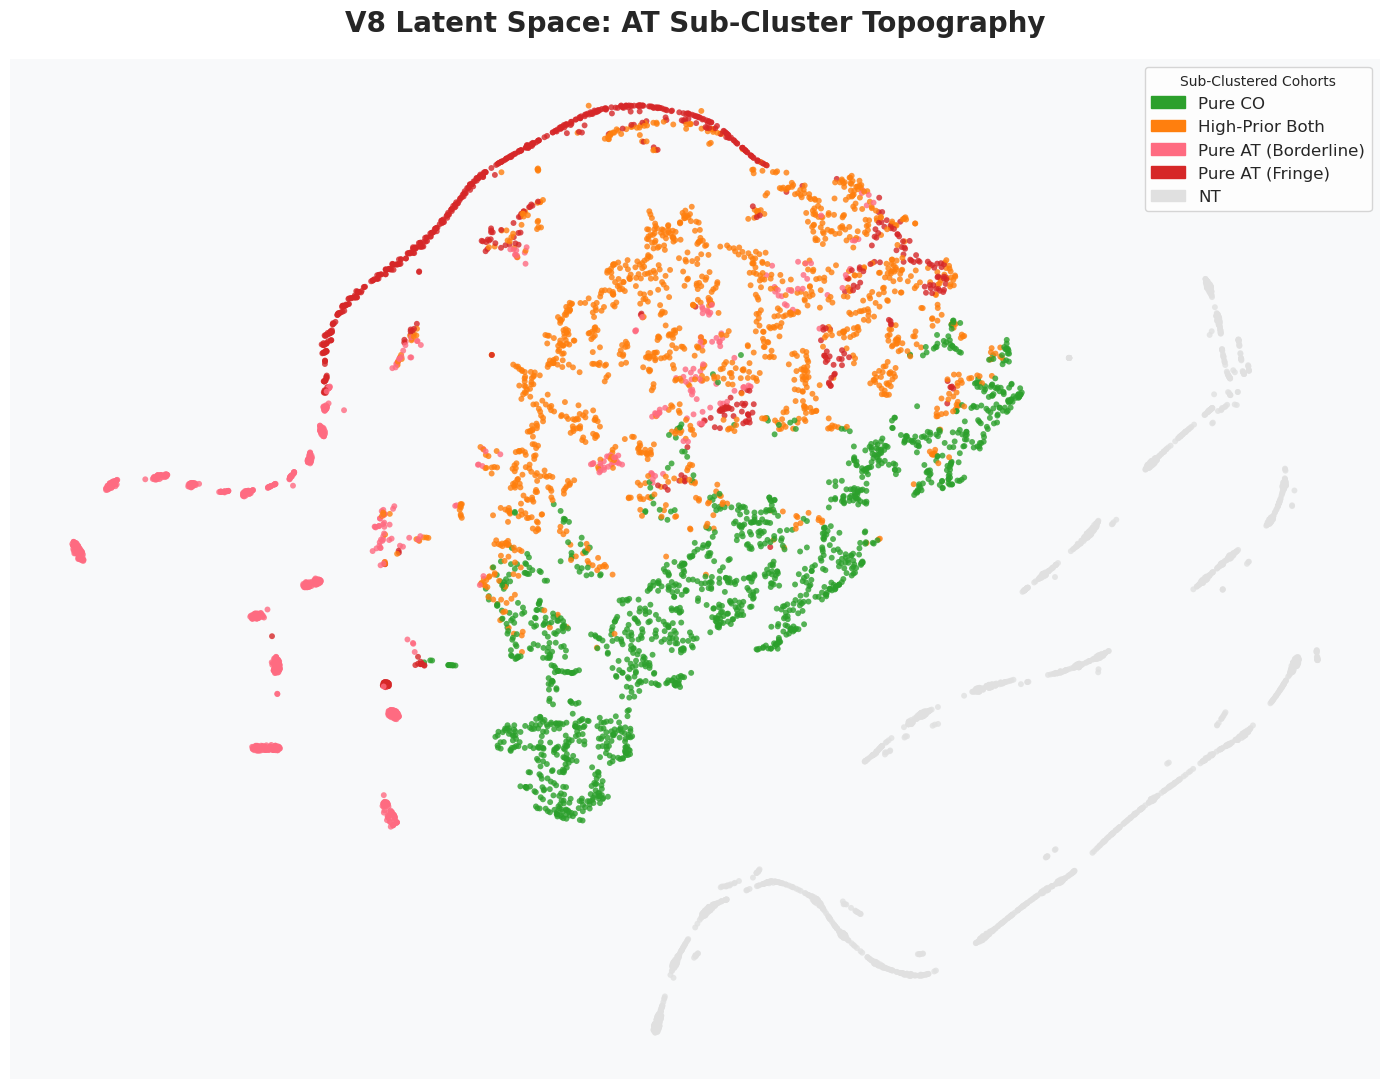

In [18]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances

# ==========================================
# 0. 目录与路径配置
# ==========================================
OUTPUT_DIR = "/NAS/shith/uplift/0420_representation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

C_PRIOR_PATH = glob.glob("/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv", recursive=True)[0]
V8_BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v8_s1_t10/run_v8_s1_t10"
V8_CSV_PATH = os.path.join(V8_BASE_DIR, "test_dist.csv")
V8_NPZ_PATH = os.path.join(V8_BASE_DIR, "test_dist_embeddings.npz")

print("📦 [1/5] Loading data...")
df_c = pd.read_csv(C_PRIOR_PATH)
df_v8 = pd.read_csv(V8_CSV_PATH)
npz_v8 = np.load(V8_NPZ_PATH)
emb_raw = npz_v8['wb_shared_emb']

# 拼接入 C 模型的中介先验
df_v8['c_uplift_prior'] = df_c['uplift_pred']

# ==========================================
# 🌟 升级点：计算全局预估排位百分比 (0=垫底, 100=最高)
# ==========================================
# 必须在下采样之前，在全局 Test Set 上计算排位，这样才有宏观基准意义！
df_v8['pred_y_rank_pct'] = df_v8['uplift_pred'].rank(pct=True) * 100
df_v8['pred_c_rank_pct'] = df_v8['c_uplift_prior'].rank(pct=True) * 100

# ==========================================
# 1. 严格因果象限划分
# ==========================================
print("🔍 [2/5] Defining Causal Cohorts (Strict Thresholds)...")
p_always = df_c['y0_prob'] 
p_comp = np.clip(df_c['y1_prob'] - df_c['y0_prob'], 0, None)
p_never = np.clip(1.0 - df_c['y1_prob'], 0, None) 

th_always = p_always.quantile(0.90)
th_comp = p_comp.quantile(0.90)
th_never = p_never.quantile(0.90) 

is_at = p_always >= th_always
is_comp = p_comp >= th_comp

# 初始化大盘标签
cohorts = pd.Series('Others', index=df_c.index)
cohorts.loc[(p_never >= th_never) & (~is_at) & (~is_comp)] = 'NT'
cohorts.loc[is_comp & (~is_at)] = 'Pure CO'
cohorts.loc[is_at & is_comp] = 'High-Prior Both'
cohorts.loc[is_at & (~is_comp)] = 'Pure AT'

df_v8['Base_Cohort'] = cohorts

# ==========================================
# 2. 均匀下采样
# ==========================================
print("⚖️ [3/5] Sampling for analysis...")
SAMPLES_PER_COHORT = 1500  
sampled_indices = []
for c in ['Pure AT', 'Pure CO', 'High-Prior Both', 'NT']:
    idx = df_v8[df_v8['Base_Cohort'] == c].index
    if len(idx) > SAMPLES_PER_COHORT:
        idx = np.random.choice(idx, SAMPLES_PER_COHORT, replace=False)
    sampled_indices.extend(idx)

df_sample = df_v8.loc[sampled_indices].copy()
emb_sample = emb_raw[sampled_indices]

# ==========================================
# 3. 核心探测：寻找“边缘 AT”与“靠岸 AT” (修复 Broadcast Bug)
# ==========================================
print("🧬 [4/5] Computing High-Dim distances to split Pure AT...")

# 拿到 High-Prior Both 的高维质心
both_idx = df_sample[df_sample['Base_Cohort'] == 'High-Prior Both'].index
both_centroid = emb_raw[both_idx].mean(axis=0).reshape(1, -1)

# 算出所有 Pure AT 到 Both 质心的距离
at_idx = df_sample[df_sample['Base_Cohort'] == 'Pure AT'].index
at_embs = emb_raw[at_idx]
distances = cosine_distances(at_embs, both_centroid).flatten()

dist_median = np.median(distances)
df_sample['Sub_Cohort'] = df_sample['Base_Cohort'].copy()

# 🌟 修复处：直接利用之前截取出来的 at_idx 内部的布尔掩码进行赋值
borderline_idx = at_idx[distances <= dist_median]
fringe_idx = at_idx[distances > dist_median]

df_sample.loc[borderline_idx, 'Sub_Cohort'] = 'Pure AT (Borderline)'
df_sample.loc[fringe_idx, 'Sub_Cohort'] = 'Pure AT (Fringe)'

# ==========================================
# 4. 统计对账单：排位能力大透视！
# ==========================================
print("\n" + "="*80)
print("📊 SUB-COHORT UPLIFT ANALYSIS (TRUE ATE vs GLOBAL RANK %)")
print("="*80)

def calc_metrics(sub_df):
    t0_mask = sub_df['t'] == 0
    t1_mask = sub_df['t'] == 1
    
    # 真实因果效应 (The Ultimate Truth Reference)
    true_y_ate = sub_df.loc[t1_mask, 'y_true'].mean() - sub_df.loc[t0_mask, 'y_true'].mean()
    true_c_ate = sub_df.loc[t1_mask, 'c_true'].mean() - sub_df.loc[t0_mask, 'c_true'].mean()
    
    # 模型预估均值与全局排位百分比 (The Model's Belief)
    pred_y_mean = sub_df['uplift_pred'].mean()
    rank_y_pct = sub_df['pred_y_rank_pct'].mean()
    
    pred_c_mean = sub_df['c_uplift_prior'].mean() 
    rank_c_pct = sub_df['pred_c_rank_pct'].mean()
    
    return true_y_ate, pred_y_mean, rank_y_pct, true_c_ate, pred_c_mean, rank_c_pct

target_groups = ['Pure CO', 'High-Prior Both', 'Pure AT (Borderline)', 'Pure AT (Fringe)', 'NT']

stats_list = []
for grp in target_groups:
    sub = df_sample[df_sample['Sub_Cohort'] == grp]
    if len(sub) == 0: continue
    ty, py, ry, tc, pc, rc = calc_metrics(sub)
    stats_list.append({
        "Cohort": grp, "Size": len(sub),
        "True_Y_ATE": ty, "Pred_Y": py, "Rank_Y(%)": ry,
        "True_C_ATE": tc, "Pred_C": pc, "Rank_C(%)": rc
    })

stats_df = pd.DataFrame(stats_list)
# 打印漂亮的对照表
print(stats_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
stats_df.to_csv(os.path.join(OUTPUT_DIR, "v8_at_subcluster_stats.csv"), index=False)

# ==========================================
# 5. 极美可视化：渐变染色 t-SNE
# ==========================================
print("\n🎨 [5/5] Rendering Sub-clustered t-SNE...")
pca_dim = min(50, emb_sample.shape[1])
emb_pca = PCA(n_components=pca_dim).fit_transform(emb_sample)
emb_2d = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000).fit_transform(emb_pca)

df_sample['tsne_1'] = emb_2d[:, 0]
df_sample['tsne_2'] = emb_2d[:, 1]

palette = {
    'Pure CO': '#2ca02c',                           
    'High-Prior Both': '#ff7f0e',                   
    'Pure AT (Borderline)': '#ff6b81',      
    'Pure AT (Fringe)': '#d62728',         
    'NT': '#e0e0e0'                                 
}

df_sample['color'] = df_sample['Sub_Cohort'].map(palette)
df_shuffled = df_sample.sample(frac=1.0, random_state=42).reset_index(drop=True)

plt.figure(figsize=(14, 11), facecolor='white')
ax = plt.axes()
ax.set_facecolor('#F8F9FA')

ax.scatter(df_shuffled['tsne_1'], df_shuffled['tsne_2'], 
           c=df_shuffled['color'], s=18, alpha=0.8, edgecolors='none')

import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=palette[c], label=c) for c in target_groups]
legend = plt.legend(handles=legend_patches, title="Sub-Clustered Cohorts", fontsize=12, loc='best', frameon=True)
legend.get_frame().set_facecolor('white')

plt.title("V8 Latent Space: AT Sub-Cluster Topography", fontsize=20, pad=20, fontweight='bold')
plt.xticks([]); plt.yticks([])
for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "v8_at_subclusters_tsne.pdf")
plt.savefig(save_path, dpi=400)
print(f"✅ Success! Plot saved to: {save_path}")

📦 [1/5] Loading data...


🔍 [2/5] Defining Causal Cohorts (Strict Thresholds)...
⚖️ [3/5] Sampling for analysis...
🧬 [4/5] Computing High-Dim distances to split Pure AT...

📊 SUB-COHORT UPLIFT ANALYSIS (TRUE ATE vs GLOBAL RANK %)
              Cohort  Size  True_Y_ATE  Pred_Y  Rank_Y(%)  True_C_ATE  Pred_C  Rank_C(%)
             Pure CO  1500     -0.0001  0.0027    74.4156      0.0702  0.0438    93.6334
     High-Prior Both  1500      0.0030  0.0154    94.2167      0.0553  0.0734    95.7666
Pure AT (Borderline)   750     -0.0101  0.0097    93.1219      0.0416 -0.0009    21.9504
    Pure AT (Fringe)   750     -0.0008  0.0130    94.2395     -0.0051  0.0023    41.0122
                  NT  1500      0.0000 -0.0008    38.3244      0.0024 -0.0005    10.0966

🎨 [5/5] Rendering Sub-clustered t-SNE...


/NAS/shith/anaconda3/envs/song1/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✅ Success! Plot saved to: /NAS/shith/uplift/0420_representation/v10_at_subclusters_tsne.pdf


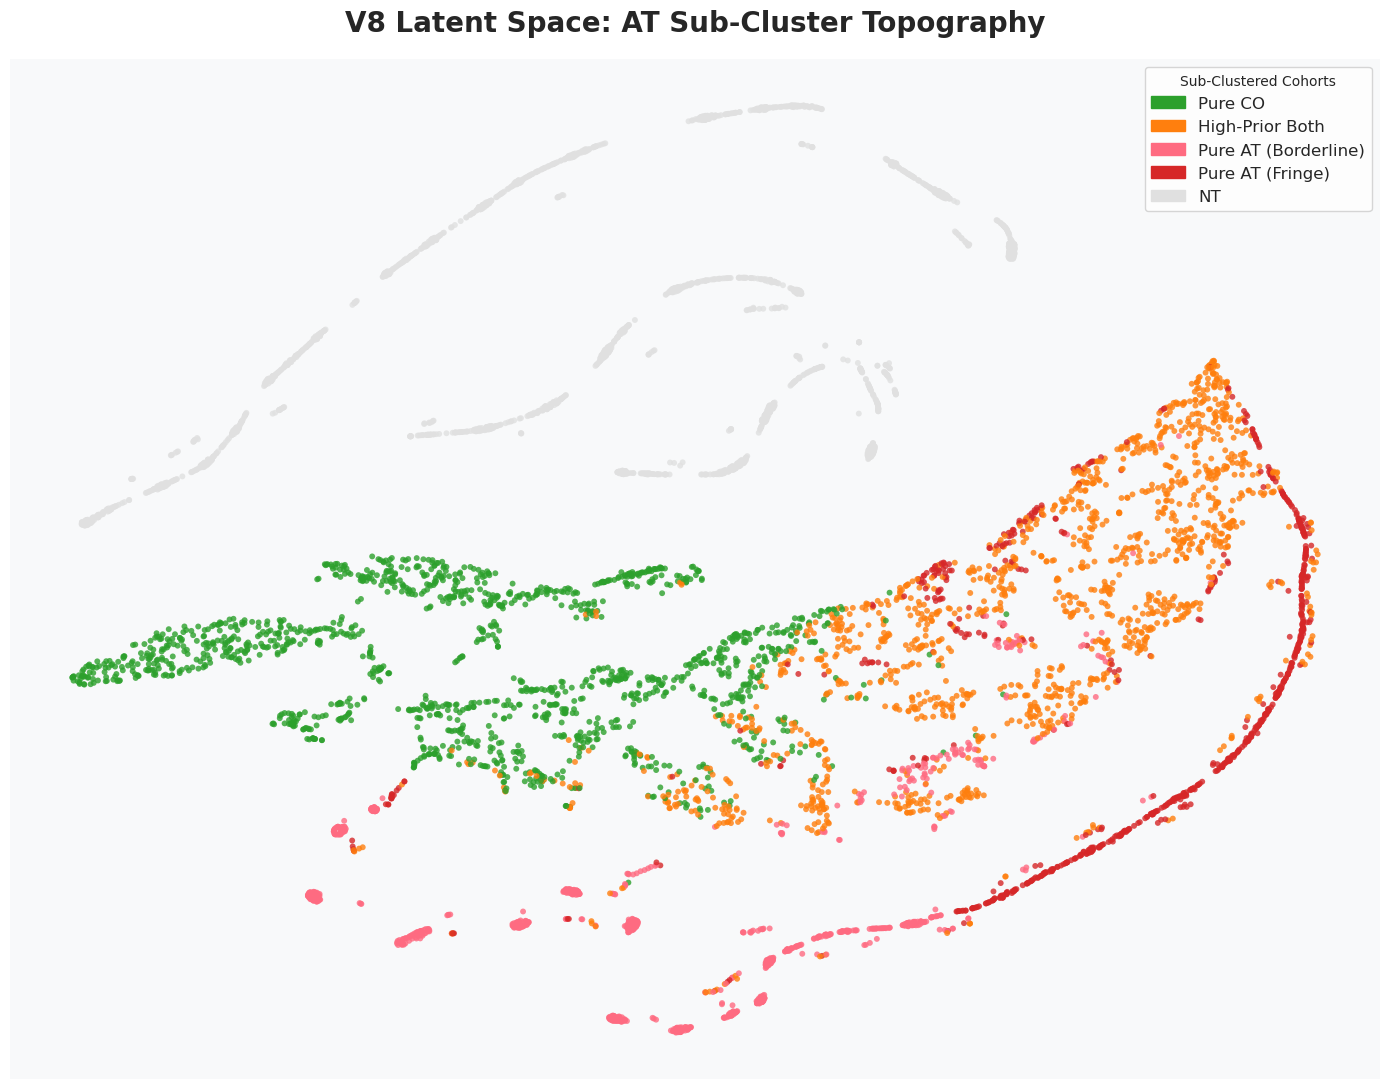

In [19]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances

# ==========================================
# 0. 目录与路径配置
# ==========================================
OUTPUT_DIR = "/NAS/shith/uplift/0420_representation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

C_PRIOR_PATH = glob.glob("/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv", recursive=True)[0]
V8_BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v10_conflict_both/run_v10_both"
V8_CSV_PATH = os.path.join(V8_BASE_DIR, "test_dist.csv")
V8_NPZ_PATH = os.path.join(V8_BASE_DIR, "test_dist_embeddings.npz")

print("📦 [1/5] Loading data...")
df_c = pd.read_csv(C_PRIOR_PATH)
df_v8 = pd.read_csv(V8_CSV_PATH)
npz_v8 = np.load(V8_NPZ_PATH)
emb_raw = npz_v8['wb_shared_emb']

# 拼接入 C 模型的中介先验
df_v8['c_uplift_prior'] = df_c['uplift_pred']

# ==========================================
# 🌟 升级点：计算全局预估排位百分比 (0=垫底, 100=最高)
# ==========================================
# 必须在下采样之前，在全局 Test Set 上计算排位，这样才有宏观基准意义！
df_v8['pred_y_rank_pct'] = df_v8['uplift_pred'].rank(pct=True) * 100
df_v8['pred_c_rank_pct'] = df_v8['c_uplift_prior'].rank(pct=True) * 100

# ==========================================
# 1. 严格因果象限划分
# ==========================================
print("🔍 [2/5] Defining Causal Cohorts (Strict Thresholds)...")
p_always = df_c['y0_prob'] 
p_comp = np.clip(df_c['y1_prob'] - df_c['y0_prob'], 0, None)
p_never = np.clip(1.0 - df_c['y1_prob'], 0, None) 

th_always = p_always.quantile(0.90)
th_comp = p_comp.quantile(0.90)
th_never = p_never.quantile(0.90) 

is_at = p_always >= th_always
is_comp = p_comp >= th_comp

# 初始化大盘标签
cohorts = pd.Series('Others', index=df_c.index)
cohorts.loc[(p_never >= th_never) & (~is_at) & (~is_comp)] = 'NT'
cohorts.loc[is_comp & (~is_at)] = 'Pure CO'
cohorts.loc[is_at & is_comp] = 'High-Prior Both'
cohorts.loc[is_at & (~is_comp)] = 'Pure AT'

df_v8['Base_Cohort'] = cohorts

# ==========================================
# 2. 均匀下采样
# ==========================================
print("⚖️ [3/5] Sampling for analysis...")
SAMPLES_PER_COHORT = 1500  
sampled_indices = []
for c in ['Pure AT', 'Pure CO', 'High-Prior Both', 'NT']:
    idx = df_v8[df_v8['Base_Cohort'] == c].index
    if len(idx) > SAMPLES_PER_COHORT:
        idx = np.random.choice(idx, SAMPLES_PER_COHORT, replace=False)
    sampled_indices.extend(idx)

df_sample = df_v8.loc[sampled_indices].copy()
emb_sample = emb_raw[sampled_indices]

# ==========================================
# 3. 核心探测：寻找“边缘 AT”与“靠岸 AT” (修复 Broadcast Bug)
# ==========================================
print("🧬 [4/5] Computing High-Dim distances to split Pure AT...")

# 拿到 High-Prior Both 的高维质心
both_idx = df_sample[df_sample['Base_Cohort'] == 'High-Prior Both'].index
both_centroid = emb_raw[both_idx].mean(axis=0).reshape(1, -1)

# 算出所有 Pure AT 到 Both 质心的距离
at_idx = df_sample[df_sample['Base_Cohort'] == 'Pure AT'].index
at_embs = emb_raw[at_idx]
distances = cosine_distances(at_embs, both_centroid).flatten()

dist_median = np.median(distances)
df_sample['Sub_Cohort'] = df_sample['Base_Cohort'].copy()

# 🌟 修复处：直接利用之前截取出来的 at_idx 内部的布尔掩码进行赋值
borderline_idx = at_idx[distances <= dist_median]
fringe_idx = at_idx[distances > dist_median]

df_sample.loc[borderline_idx, 'Sub_Cohort'] = 'Pure AT (Borderline)'
df_sample.loc[fringe_idx, 'Sub_Cohort'] = 'Pure AT (Fringe)'

# ==========================================
# 4. 统计对账单：排位能力大透视！
# ==========================================
print("\n" + "="*80)
print("📊 SUB-COHORT UPLIFT ANALYSIS (TRUE ATE vs GLOBAL RANK %)")
print("="*80)

def calc_metrics(sub_df):
    t0_mask = sub_df['t'] == 0
    t1_mask = sub_df['t'] == 1
    
    # 真实因果效应 (The Ultimate Truth Reference)
    true_y_ate = sub_df.loc[t1_mask, 'y_true'].mean() - sub_df.loc[t0_mask, 'y_true'].mean()
    true_c_ate = sub_df.loc[t1_mask, 'c_true'].mean() - sub_df.loc[t0_mask, 'c_true'].mean()
    
    # 模型预估均值与全局排位百分比 (The Model's Belief)
    pred_y_mean = sub_df['uplift_pred'].mean()
    rank_y_pct = sub_df['pred_y_rank_pct'].mean()
    
    pred_c_mean = sub_df['c_uplift_prior'].mean() 
    rank_c_pct = sub_df['pred_c_rank_pct'].mean()
    
    return true_y_ate, pred_y_mean, rank_y_pct, true_c_ate, pred_c_mean, rank_c_pct

target_groups = ['Pure CO', 'High-Prior Both', 'Pure AT (Borderline)', 'Pure AT (Fringe)', 'NT']

stats_list = []
for grp in target_groups:
    sub = df_sample[df_sample['Sub_Cohort'] == grp]
    if len(sub) == 0: continue
    ty, py, ry, tc, pc, rc = calc_metrics(sub)
    stats_list.append({
        "Cohort": grp, "Size": len(sub),
        "True_Y_ATE": ty, "Pred_Y": py, "Rank_Y(%)": ry,
        "True_C_ATE": tc, "Pred_C": pc, "Rank_C(%)": rc
    })

stats_df = pd.DataFrame(stats_list)
# 打印漂亮的对照表
print(stats_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
stats_df.to_csv(os.path.join(OUTPUT_DIR, "v10_at_subcluster_stats.csv"), index=False)

# ==========================================
# 5. 极美可视化：渐变染色 t-SNE
# ==========================================
print("\n🎨 [5/5] Rendering Sub-clustered t-SNE...")
pca_dim = min(50, emb_sample.shape[1])
emb_pca = PCA(n_components=pca_dim).fit_transform(emb_sample)
emb_2d = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000).fit_transform(emb_pca)

df_sample['tsne_1'] = emb_2d[:, 0]
df_sample['tsne_2'] = emb_2d[:, 1]

palette = {
    'Pure CO': '#2ca02c',                           
    'High-Prior Both': '#ff7f0e',                   
    'Pure AT (Borderline)': '#ff6b81',      
    'Pure AT (Fringe)': '#d62728',         
    'NT': '#e0e0e0'                                 
}

df_sample['color'] = df_sample['Sub_Cohort'].map(palette)
df_shuffled = df_sample.sample(frac=1.0, random_state=42).reset_index(drop=True)

plt.figure(figsize=(14, 11), facecolor='white')
ax = plt.axes()
ax.set_facecolor('#F8F9FA')

ax.scatter(df_shuffled['tsne_1'], df_shuffled['tsne_2'], 
           c=df_shuffled['color'], s=18, alpha=0.8, edgecolors='none')

import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=palette[c], label=c) for c in target_groups]
legend = plt.legend(handles=legend_patches, title="Sub-Clustered Cohorts", fontsize=12, loc='best', frameon=True)
legend.get_frame().set_facecolor('white')

plt.title("V8 Latent Space: AT Sub-Cluster Topography", fontsize=20, pad=20, fontweight='bold')
plt.xticks([]); plt.yticks([])
for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "v10_at_subclusters_tsne.pdf")
plt.savefig(save_path, dpi=400)
print(f"✅ Success! Plot saved to: {save_path}")

📦 [1/5] Loading data...


🔍 [2/5] Defining Causal Cohorts (Strict Thresholds)...
⚖️ [3/5] Sampling for analysis...
🧬 [4/5] Computing High-Dim distances to split Pure AT...

📊 SUB-COHORT UPLIFT ANALYSIS (TRUE ATE vs GLOBAL RANK %)
              Cohort  Size  True_Y_ATE  Pred_Y  Rank_Y(%)  True_C_ATE  Pred_C  Rank_C(%)
             Pure CO  1500      0.0008  0.0002    63.7781      0.0678  0.0431    93.5560
     High-Prior Both  1500      0.0142  0.0096    95.0983      0.1054  0.0744    95.8045
Pure AT (Borderline)   750     -0.0071  0.0013    93.4100      0.0053  0.0010    32.0659
    Pure AT (Fringe)   750     -0.0037  0.0030    93.1911      0.0080  0.0008    33.1879
                  NT  1500      0.0000  0.0000    11.9130     -0.0029 -0.0005     9.9654

🎨 [5/5] Rendering Sub-clustered t-SNE...


/NAS/shith/anaconda3/envs/song1/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✅ Success! Plot saved to: /NAS/shith/uplift/0420_representation/v6_at_subclusters_tsne.pdf


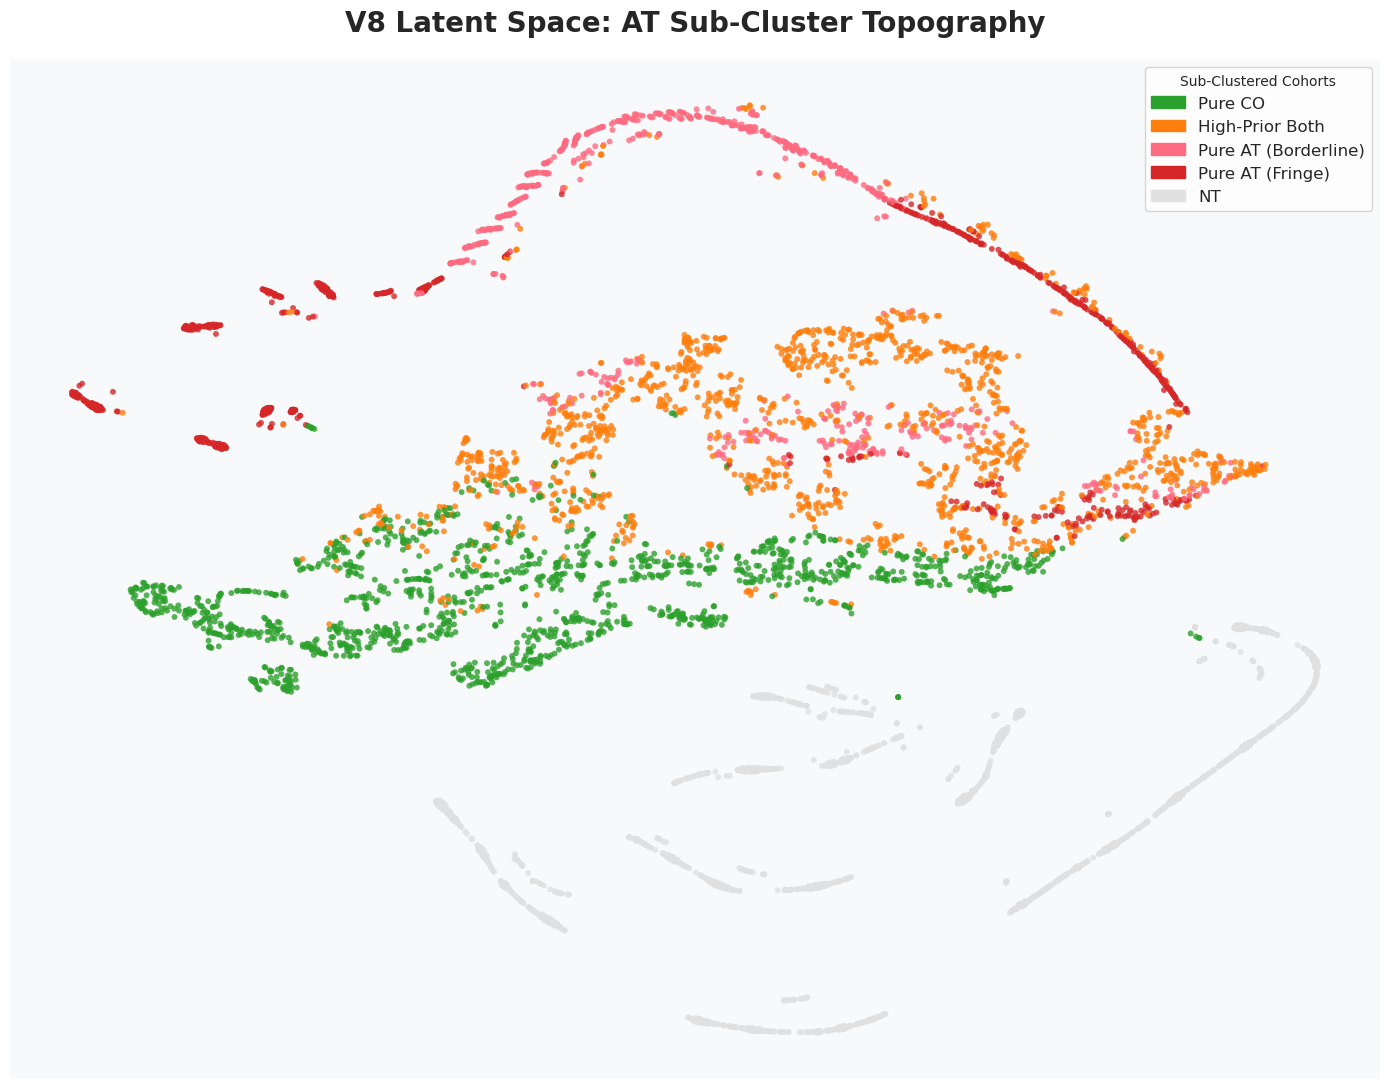

In [20]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances

# ==========================================
# 0. 目录与路径配置
# ==========================================
OUTPUT_DIR = "/NAS/shith/uplift/0420_representation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

C_PRIOR_PATH = glob.glob("/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv", recursive=True)[0]
V8_BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v6_res_moe/run_v6_res_moe"
V8_CSV_PATH = os.path.join(V8_BASE_DIR, "test_dist.csv")
V8_NPZ_PATH = os.path.join(V8_BASE_DIR, "test_dist_embeddings.npz")

print("📦 [1/5] Loading data...")
df_c = pd.read_csv(C_PRIOR_PATH)
df_v8 = pd.read_csv(V8_CSV_PATH)
npz_v8 = np.load(V8_NPZ_PATH)
emb_raw = npz_v8['wb_shared_emb']

# 拼接入 C 模型的中介先验
df_v8['c_uplift_prior'] = df_c['uplift_pred']

# ==========================================
# 🌟 升级点：计算全局预估排位百分比 (0=垫底, 100=最高)
# ==========================================
# 必须在下采样之前，在全局 Test Set 上计算排位，这样才有宏观基准意义！
df_v8['pred_y_rank_pct'] = df_v8['uplift_pred'].rank(pct=True) * 100
df_v8['pred_c_rank_pct'] = df_v8['c_uplift_prior'].rank(pct=True) * 100

# ==========================================
# 1. 严格因果象限划分
# ==========================================
print("🔍 [2/5] Defining Causal Cohorts (Strict Thresholds)...")
p_always = df_c['y0_prob'] 
p_comp = np.clip(df_c['y1_prob'] - df_c['y0_prob'], 0, None)
p_never = np.clip(1.0 - df_c['y1_prob'], 0, None) 

th_always = p_always.quantile(0.90)
th_comp = p_comp.quantile(0.90)
th_never = p_never.quantile(0.90) 

is_at = p_always >= th_always
is_comp = p_comp >= th_comp

# 初始化大盘标签
cohorts = pd.Series('Others', index=df_c.index)
cohorts.loc[(p_never >= th_never) & (~is_at) & (~is_comp)] = 'NT'
cohorts.loc[is_comp & (~is_at)] = 'Pure CO'
cohorts.loc[is_at & is_comp] = 'High-Prior Both'
cohorts.loc[is_at & (~is_comp)] = 'Pure AT'

df_v8['Base_Cohort'] = cohorts

# ==========================================
# 2. 均匀下采样
# ==========================================
print("⚖️ [3/5] Sampling for analysis...")
SAMPLES_PER_COHORT = 1500  
sampled_indices = []
for c in ['Pure AT', 'Pure CO', 'High-Prior Both', 'NT']:
    idx = df_v8[df_v8['Base_Cohort'] == c].index
    if len(idx) > SAMPLES_PER_COHORT:
        idx = np.random.choice(idx, SAMPLES_PER_COHORT, replace=False)
    sampled_indices.extend(idx)

df_sample = df_v8.loc[sampled_indices].copy()
emb_sample = emb_raw[sampled_indices]

# ==========================================
# 3. 核心探测：寻找“边缘 AT”与“靠岸 AT” (修复 Broadcast Bug)
# ==========================================
print("🧬 [4/5] Computing High-Dim distances to split Pure AT...")

# 拿到 High-Prior Both 的高维质心
both_idx = df_sample[df_sample['Base_Cohort'] == 'High-Prior Both'].index
both_centroid = emb_raw[both_idx].mean(axis=0).reshape(1, -1)

# 算出所有 Pure AT 到 Both 质心的距离
at_idx = df_sample[df_sample['Base_Cohort'] == 'Pure AT'].index
at_embs = emb_raw[at_idx]
distances = cosine_distances(at_embs, both_centroid).flatten()

dist_median = np.median(distances)
df_sample['Sub_Cohort'] = df_sample['Base_Cohort'].copy()

# 🌟 修复处：直接利用之前截取出来的 at_idx 内部的布尔掩码进行赋值
borderline_idx = at_idx[distances <= dist_median]
fringe_idx = at_idx[distances > dist_median]

df_sample.loc[borderline_idx, 'Sub_Cohort'] = 'Pure AT (Borderline)'
df_sample.loc[fringe_idx, 'Sub_Cohort'] = 'Pure AT (Fringe)'

# ==========================================
# 4. 统计对账单：排位能力大透视！
# ==========================================
print("\n" + "="*80)
print("📊 SUB-COHORT UPLIFT ANALYSIS (TRUE ATE vs GLOBAL RANK %)")
print("="*80)

def calc_metrics(sub_df):
    t0_mask = sub_df['t'] == 0
    t1_mask = sub_df['t'] == 1
    
    # 真实因果效应 (The Ultimate Truth Reference)
    true_y_ate = sub_df.loc[t1_mask, 'y_true'].mean() - sub_df.loc[t0_mask, 'y_true'].mean()
    true_c_ate = sub_df.loc[t1_mask, 'c_true'].mean() - sub_df.loc[t0_mask, 'c_true'].mean()
    
    # 模型预估均值与全局排位百分比 (The Model's Belief)
    pred_y_mean = sub_df['uplift_pred'].mean()
    rank_y_pct = sub_df['pred_y_rank_pct'].mean()
    
    pred_c_mean = sub_df['c_uplift_prior'].mean() 
    rank_c_pct = sub_df['pred_c_rank_pct'].mean()
    
    return true_y_ate, pred_y_mean, rank_y_pct, true_c_ate, pred_c_mean, rank_c_pct

target_groups = ['Pure CO', 'High-Prior Both', 'Pure AT (Borderline)', 'Pure AT (Fringe)', 'NT']

stats_list = []
for grp in target_groups:
    sub = df_sample[df_sample['Sub_Cohort'] == grp]
    if len(sub) == 0: continue
    ty, py, ry, tc, pc, rc = calc_metrics(sub)
    stats_list.append({
        "Cohort": grp, "Size": len(sub),
        "True_Y_ATE": ty, "Pred_Y": py, "Rank_Y(%)": ry,
        "True_C_ATE": tc, "Pred_C": pc, "Rank_C(%)": rc
    })

stats_df = pd.DataFrame(stats_list)
# 打印漂亮的对照表
print(stats_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
stats_df.to_csv(os.path.join(OUTPUT_DIR, "v8_at_subcluster_stats.csv"), index=False)

# ==========================================
# 5. 极美可视化：渐变染色 t-SNE
# ==========================================
print("\n🎨 [5/5] Rendering Sub-clustered t-SNE...")
pca_dim = min(50, emb_sample.shape[1])
emb_pca = PCA(n_components=pca_dim).fit_transform(emb_sample)
emb_2d = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000).fit_transform(emb_pca)

df_sample['tsne_1'] = emb_2d[:, 0]
df_sample['tsne_2'] = emb_2d[:, 1]

palette = {
    'Pure CO': '#2ca02c',                           
    'High-Prior Both': '#ff7f0e',                   
    'Pure AT (Borderline)': '#ff6b81',      
    'Pure AT (Fringe)': '#d62728',         
    'NT': '#e0e0e0'                                 
}

df_sample['color'] = df_sample['Sub_Cohort'].map(palette)
df_shuffled = df_sample.sample(frac=1.0, random_state=42).reset_index(drop=True)

plt.figure(figsize=(14, 11), facecolor='white')
ax = plt.axes()
ax.set_facecolor('#F8F9FA')

ax.scatter(df_shuffled['tsne_1'], df_shuffled['tsne_2'], 
           c=df_shuffled['color'], s=18, alpha=0.8, edgecolors='none')

import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=palette[c], label=c) for c in target_groups]
legend = plt.legend(handles=legend_patches, title="Sub-Clustered Cohorts", fontsize=12, loc='best', frameon=True)
legend.get_frame().set_facecolor('white')

plt.title("V8 Latent Space: AT Sub-Cluster Topography", fontsize=20, pad=20, fontweight='bold')
plt.xticks([]); plt.yticks([])
for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "v6_at_subclusters_tsne.pdf")
plt.savefig(save_path, dpi=400)
print(f"✅ Success! Plot saved to: {save_path}")

📦 [1/5] Loading data...


🔍 [2/5] Defining Causal Cohorts (Strict Thresholds)...
⚖️ [3/5] Sampling for analysis...
🧬 [4/5] Computing High-Dim distances to split Pure AT...

📊 SUB-COHORT UPLIFT ANALYSIS (TRUE ATE vs GLOBAL RANK %)
              Cohort  Size  True_Y_ATE  Pred_Y  Rank_Y(%)  True_C_ATE  Pred_C  Rank_C(%)
             Pure CO  1500      0.0039  0.0004    64.3118      0.0380  0.0444    93.7013
     High-Prior Both  1500      0.0218  0.0086    92.5907      0.0659  0.0753    95.9129
Pure AT (Borderline)   750      0.0032  0.0066    95.8947     -0.1026  0.0017    37.9306
    Pure AT (Fringe)   750      0.0049  0.0019    91.7142      0.0426 -0.0005    24.9024
                  NT  1500      0.0000 -0.0001    71.3295      0.0024 -0.0005    10.0369

🎨 [5/5] Rendering Sub-clustered t-SNE...


/NAS/shith/anaconda3/envs/song1/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✅ Success! Plot saved to: /NAS/shith/uplift/0420_representation/v1_at_subclusters_tsne.pdf


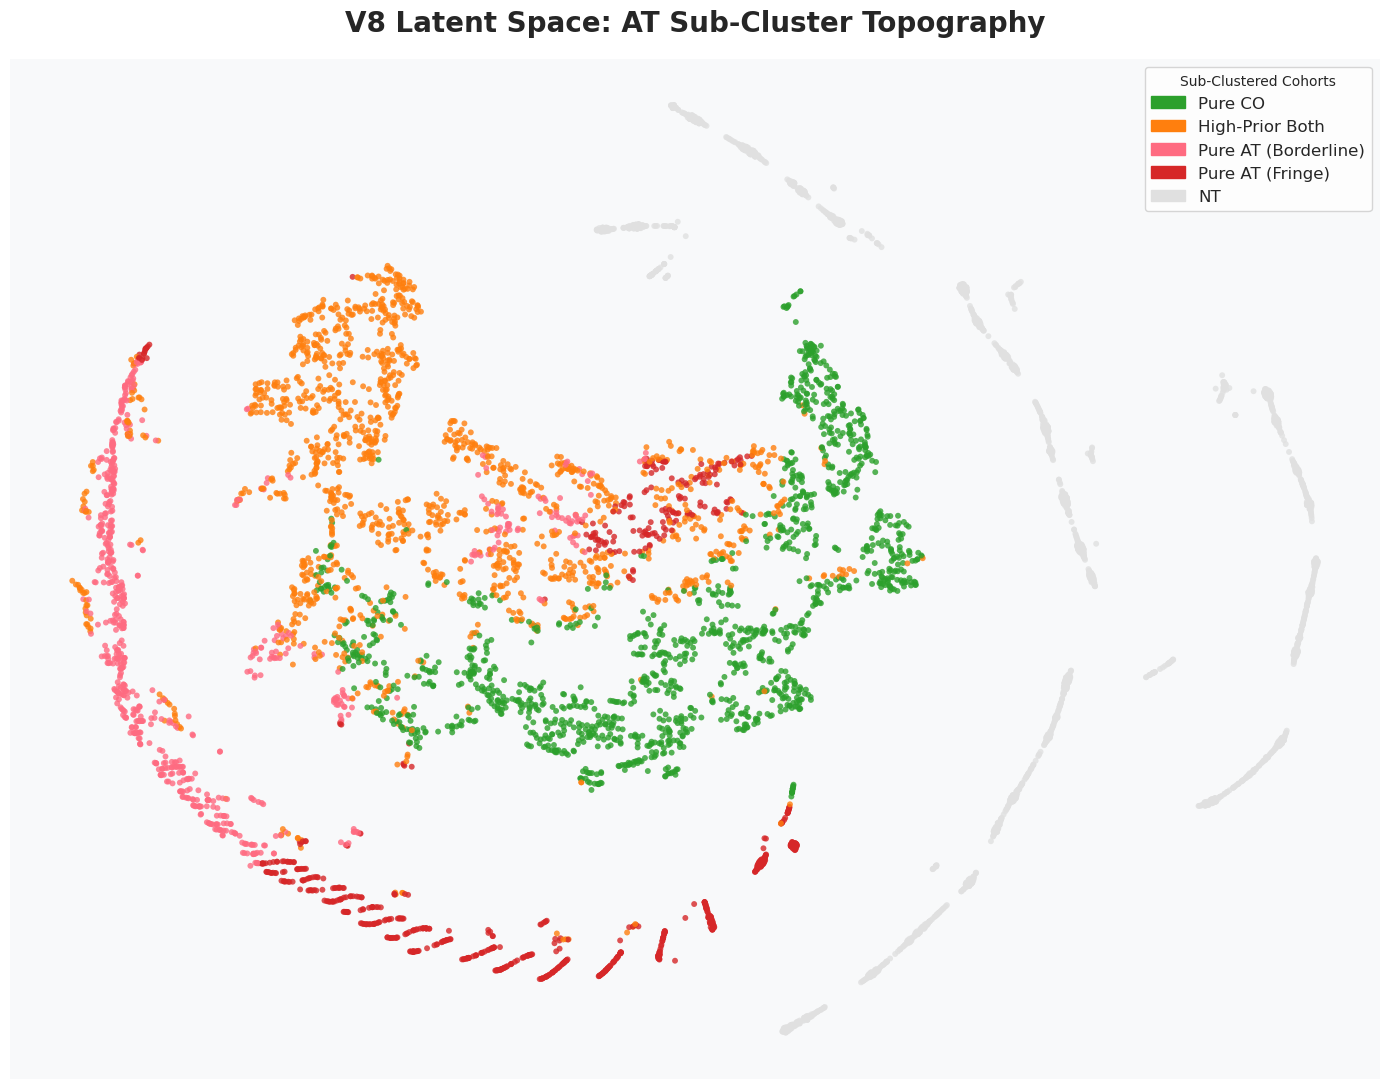

In [21]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances

# ==========================================
# 0. 目录与路径配置
# ==========================================
OUTPUT_DIR = "/NAS/shith/uplift/0420_representation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

C_PRIOR_PATH = glob.glob("/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv", recursive=True)[0]
V8_BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/TARNET/y_v1_base/run_v1_base"
V8_CSV_PATH = os.path.join(V8_BASE_DIR, "test_dist.csv")
V8_NPZ_PATH = os.path.join(V8_BASE_DIR, "test_dist_embeddings.npz")

print("📦 [1/5] Loading data...")
df_c = pd.read_csv(C_PRIOR_PATH)
df_v8 = pd.read_csv(V8_CSV_PATH)
npz_v8 = np.load(V8_NPZ_PATH)
emb_raw = npz_v8['wb_shared_emb']

# 拼接入 C 模型的中介先验
df_v8['c_uplift_prior'] = df_c['uplift_pred']

# ==========================================
# 🌟 升级点：计算全局预估排位百分比 (0=垫底, 100=最高)
# ==========================================
# 必须在下采样之前，在全局 Test Set 上计算排位，这样才有宏观基准意义！
df_v8['pred_y_rank_pct'] = df_v8['uplift_pred'].rank(pct=True) * 100
df_v8['pred_c_rank_pct'] = df_v8['c_uplift_prior'].rank(pct=True) * 100

# ==========================================
# 1. 严格因果象限划分
# ==========================================
print("🔍 [2/5] Defining Causal Cohorts (Strict Thresholds)...")
p_always = df_c['y0_prob'] 
p_comp = np.clip(df_c['y1_prob'] - df_c['y0_prob'], 0, None)
p_never = np.clip(1.0 - df_c['y1_prob'], 0, None) 

th_always = p_always.quantile(0.90)
th_comp = p_comp.quantile(0.90)
th_never = p_never.quantile(0.90) 

is_at = p_always >= th_always
is_comp = p_comp >= th_comp

# 初始化大盘标签
cohorts = pd.Series('Others', index=df_c.index)
cohorts.loc[(p_never >= th_never) & (~is_at) & (~is_comp)] = 'NT'
cohorts.loc[is_comp & (~is_at)] = 'Pure CO'
cohorts.loc[is_at & is_comp] = 'High-Prior Both'
cohorts.loc[is_at & (~is_comp)] = 'Pure AT'

df_v8['Base_Cohort'] = cohorts

# ==========================================
# 2. 均匀下采样
# ==========================================
print("⚖️ [3/5] Sampling for analysis...")
SAMPLES_PER_COHORT = 1500  
sampled_indices = []
for c in ['Pure AT', 'Pure CO', 'High-Prior Both', 'NT']:
    idx = df_v8[df_v8['Base_Cohort'] == c].index
    if len(idx) > SAMPLES_PER_COHORT:
        idx = np.random.choice(idx, SAMPLES_PER_COHORT, replace=False)
    sampled_indices.extend(idx)

df_sample = df_v8.loc[sampled_indices].copy()
emb_sample = emb_raw[sampled_indices]

# ==========================================
# 3. 核心探测：寻找“边缘 AT”与“靠岸 AT” (修复 Broadcast Bug)
# ==========================================
print("🧬 [4/5] Computing High-Dim distances to split Pure AT...")

# 拿到 High-Prior Both 的高维质心
both_idx = df_sample[df_sample['Base_Cohort'] == 'High-Prior Both'].index
both_centroid = emb_raw[both_idx].mean(axis=0).reshape(1, -1)

# 算出所有 Pure AT 到 Both 质心的距离
at_idx = df_sample[df_sample['Base_Cohort'] == 'Pure AT'].index
at_embs = emb_raw[at_idx]
distances = cosine_distances(at_embs, both_centroid).flatten()

dist_median = np.median(distances)
df_sample['Sub_Cohort'] = df_sample['Base_Cohort'].copy()

# 🌟 修复处：直接利用之前截取出来的 at_idx 内部的布尔掩码进行赋值
borderline_idx = at_idx[distances <= dist_median]
fringe_idx = at_idx[distances > dist_median]

df_sample.loc[borderline_idx, 'Sub_Cohort'] = 'Pure AT (Borderline)'
df_sample.loc[fringe_idx, 'Sub_Cohort'] = 'Pure AT (Fringe)'

# ==========================================
# 4. 统计对账单：排位能力大透视！
# ==========================================
print("\n" + "="*80)
print("📊 SUB-COHORT UPLIFT ANALYSIS (TRUE ATE vs GLOBAL RANK %)")
print("="*80)

def calc_metrics(sub_df):
    t0_mask = sub_df['t'] == 0
    t1_mask = sub_df['t'] == 1
    
    # 真实因果效应 (The Ultimate Truth Reference)
    true_y_ate = sub_df.loc[t1_mask, 'y_true'].mean() - sub_df.loc[t0_mask, 'y_true'].mean()
    true_c_ate = sub_df.loc[t1_mask, 'c_true'].mean() - sub_df.loc[t0_mask, 'c_true'].mean()
    
    # 模型预估均值与全局排位百分比 (The Model's Belief)
    pred_y_mean = sub_df['uplift_pred'].mean()
    rank_y_pct = sub_df['pred_y_rank_pct'].mean()
    
    pred_c_mean = sub_df['c_uplift_prior'].mean() 
    rank_c_pct = sub_df['pred_c_rank_pct'].mean()
    
    return true_y_ate, pred_y_mean, rank_y_pct, true_c_ate, pred_c_mean, rank_c_pct

target_groups = ['Pure CO', 'High-Prior Both', 'Pure AT (Borderline)', 'Pure AT (Fringe)', 'NT']

stats_list = []
for grp in target_groups:
    sub = df_sample[df_sample['Sub_Cohort'] == grp]
    if len(sub) == 0: continue
    ty, py, ry, tc, pc, rc = calc_metrics(sub)
    stats_list.append({
        "Cohort": grp, "Size": len(sub),
        "True_Y_ATE": ty, "Pred_Y": py, "Rank_Y(%)": ry,
        "True_C_ATE": tc, "Pred_C": pc, "Rank_C(%)": rc
    })

stats_df = pd.DataFrame(stats_list)
# 打印漂亮的对照表
print(stats_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
stats_df.to_csv(os.path.join(OUTPUT_DIR, "v1_at_subcluster_stats.csv"), index=False)

# ==========================================
# 5. 极美可视化：渐变染色 t-SNE
# ==========================================
print("\n🎨 [5/5] Rendering Sub-clustered t-SNE...")
pca_dim = min(50, emb_sample.shape[1])
emb_pca = PCA(n_components=pca_dim).fit_transform(emb_sample)
emb_2d = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000).fit_transform(emb_pca)

df_sample['tsne_1'] = emb_2d[:, 0]
df_sample['tsne_2'] = emb_2d[:, 1]

palette = {
    'Pure CO': '#2ca02c',                           
    'High-Prior Both': '#ff7f0e',                   
    'Pure AT (Borderline)': '#ff6b81',      
    'Pure AT (Fringe)': '#d62728',         
    'NT': '#e0e0e0'                                 
}

df_sample['color'] = df_sample['Sub_Cohort'].map(palette)
df_shuffled = df_sample.sample(frac=1.0, random_state=42).reset_index(drop=True)

plt.figure(figsize=(14, 11), facecolor='white')
ax = plt.axes()
ax.set_facecolor('#F8F9FA')

ax.scatter(df_shuffled['tsne_1'], df_shuffled['tsne_2'], 
           c=df_shuffled['color'], s=18, alpha=0.8, edgecolors='none')

import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=palette[c], label=c) for c in target_groups]
legend = plt.legend(handles=legend_patches, title="Sub-Clustered Cohorts", fontsize=12, loc='best', frameon=True)
legend.get_frame().set_facecolor('white')

plt.title("V8 Latent Space: AT Sub-Cluster Topography", fontsize=20, pad=20, fontweight='bold')
plt.xticks([]); plt.yticks([])
for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "v1_at_subclusters_tsne.pdf")
plt.savefig(save_path, dpi=400)
print(f"✅ Success! Plot saved to: {save_path}")